<a href="https://colab.research.google.com/github/DOO0K/Auto-Ring/blob/main/vit_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Training a ViT on CIFAR-10
Training a Vision Transformer from scratch on a small dataset like CIFAR-10 is a known challenge. The original ViT paper demonstrated that these models require massive datasets to outperform CNNs. This project's core challenge was to overcome this limitation by building a robust pipeline that incorporates a suite of modern, data-efficient training techniques.

The following sections detail the step-by-step implementation, highlighting the key decisions and optimizations made at each stage.
Table of contents
1. Dependencies
2. Configurations
3. Model
4. DataLoader
5. Evaluator
6. Training
7. Experiments
8. Evaluate Best Trained ViT Model

# Dependencies

In [1]:
import random
import numpy as np
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.nn import Softmax, GELU
from dataclasses import dataclass
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import collections
from torchvision.transforms.v2 import MixUp, CutMix

import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR

from einops import rearrange, repeat
from tqdm import tqdm
import pandas as pd


In [2]:
# --- to save the model without losing it. ---
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Configurations

In [3]:
@dataclass
class ImageParams:
    width: int
    height: int
    in_channel: int
@dataclass
class ModelParameters:
    patch_size: int
    inner_dim: int
    transformer_layers: int
    num_head: int
    embed_dropout: float
    attn_dropout: float
    mlp_dropout: float
@dataclass
class Hyperparameters:
    batch_size: int
    out_classes: int
    epochs: int
    learning_rate: float
    weight_decay: float


# Model
* **Core Components:** The architecture is broken down into logical `nn.Module` classes: `PatchEmbedding`, `MultiHeadAttention`, `MLP`, and `TransformerEncoderBlock`.

* **Efficient Patching:** Instead of manually slicing and embedding image patches, a more efficient method was used: a single `nn.Conv2d` layer. With a `kernel_size` and `stride` equal to the `patch_size`, this layer performs both the *non-overlapped* patching and the linear projection into the embedding dimension in one highly optimized operation.

* **Stable Architecture (Pre-Norm):** While the original Transformer used a "Post-Norm" structure (LayerNorm *after* the residual connection), we have adopted the more stable **"Pre-Norm"** configuration. Applying `LayerNorm` *before* the Multi-Head Attention and MLP blocks leads to smoother gradients and more stable training.

* **Model Sizing:** Recognizing the risk of overfitting on CIFAR-10, a smaller model variant was chosen. The architecture follows the **DeiT-Ti (Tiny)** specification (`dim=192`, `depth=12`, `heads=3`), providing a better capacity-to-data ratio.


In [4]:
class PatchEmbedding(nn.Module):
    def __init__(self, mparams, hparams, img_info):
        super(PatchEmbedding, self).__init__()
        self.patch_size = mparams.patch_size
        self.img_size = img_info.width
        self.num_patches = (self.img_size//self.patch_size) * (self.img_size//self.patch_size)
        self.D = mparams.inner_dim
        self.patch_embed = nn.Conv2d(
            in_channels=img_info.in_channel,
            out_channels=self.D,
            kernel_size=self.patch_size,
            stride=self.patch_size
        )
        self.cls_token = nn.Parameter(torch.rand(1,1,self.D))

    def forward(self, x):
        # Input: [B, C, H, W]
        # Output: [B, N, D] here N is selected num_patches(from image) + 1 (cls token)
        b = x.shape[0]
        cls_token = repeat(self.cls_token, '1 1 d -> b 1 d', b=b)
        x = self.patch_embed(x)
        x = rearrange(x, 'b d h w -> b (h w) d')
        x = torch.cat((cls_token, x), dim=1)
        return x
class MHA(nn.Module):
    def __init__(self, mparams, hparams):
        super(MHA, self).__init__()
        self.D = mparams.inner_dim
        self.num_head = mparams.num_head
        assert self.D % self.num_head == 0 , 'Inner dimensions and number of attention head need to be perfectly divisible'
        self.head_size = self.D // self.num_head
        self.all_head_size = self.head_size * self.num_head
        # Set up QKV
        self.query = nn.Linear(in_features=self.D, out_features=self.all_head_size)
        self.key = nn.Linear(in_features=self.D, out_features=self.all_head_size)
        self.value = nn.Linear(in_features=self.D, out_features=self.all_head_size)
        self.output = nn.Linear(in_features=self.D, out_features=self.D)
        self.attn_dropout = nn.Dropout(mparams.attn_dropout)
        self.proj_dropout = nn.Dropout(mparams.attn_dropout)
        self.softmax = Softmax(dim=-1)
    def forward(self, x, mask= None):
        # Input: [B, N, D]
        # For atten: [B, num_head, num_patches, head_size]
        # Output: [B, N, D]
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)
        # For atten: [B, num_head, num_patches, head_size]
        q = rearrange(q, 'b n (h d) -> b h n d', h=self.num_head)
        k = rearrange(k, 'b n (h d) -> b h n d', h=self.num_head)
        v = rearrange(v, 'b n (h d) -> b h n d', h=self.num_head)
        attn_score = torch.matmul(q, k.transpose(-1, -2))/ self.head_size**0.5
        if mask is not None:
            attn_score = attn_score.masked_fill(mask == 0, -1e9)
        attn_probs = self.softmax(attn_score)
        attn_probs = self.attn_dropout(attn_probs)
         # sum with V
        context = torch.matmul(attn_probs,v) #[B,h,n,d]
        # combine all heads
        context = rearrange(context, 'b h n d -> b n (h d) ')
        output = self.output(context)
        output = self.proj_dropout(output)
        return output
class MLP(nn.Module):
    def __init__(self, mparams, hparams):
        super().__init__()
        self.D = mparams.inner_dim
        self.hidden_dim = 4* self.D
        self.net = nn.Sequential(
            nn.Linear(self.D, self.hidden_dim),
            nn.GELU(),
            nn.Dropout(mparams.mlp_dropout),
            nn.Linear(self.hidden_dim, self.D),
            nn.Dropout(mparams.mlp_dropout)
        )
    def forward(self, x):
        return self.net(x)
class EncoderBlock(nn.Module):
    def __init__(self, mparams, hparams):
        super().__init__()
        self.norm1 = nn.LayerNorm(mparams.inner_dim)
        self.attn = MHA(mparams=mparams, hparams=hparams)
        self.norm2 = nn.LayerNorm(mparams.inner_dim)
        self.ffn = MLP(mparams=mparams, hparams=hparams)
    def forward(self, x):
        residual = x
        x = self.norm1(x)
        x = self.attn(x) + residual

        residual = x
        x = self.norm2(x)
        x = self.ffn(x) + residual
        return x
class Transformer(nn.Module):
    def __init__(self, mparams, hparams):
        super().__init__()
        self.depth = mparams.transformer_layers
        self.layers = nn.ModuleList([
            EncoderBlock(mparams=mparams, hparams=hparams) for _ in range(self.depth)
        ])
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
class ViT(nn.Module):
    def __init__(self, mparams, hparams, img_info):
        super().__init__()
        image_width = img_info.width
        patch_size = mparams.patch_size
        num_patches = (image_width//patch_size)**2
        self.pos_embed = nn.Parameter(torch.rand(1, num_patches+1, mparams.inner_dim))
        self.patch_embed = PatchEmbedding(mparams=mparams, hparams=hparams, img_info=img_info)
        self.transformer = Transformer(mparams=mparams, hparams=hparams)
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(mparams.inner_dim),
            nn.Linear(mparams.inner_dim, hparams.out_classes)
        )
        self.embed_dropout = nn.Dropout(mparams.embed_dropout)
    def forward(self, x):
        x = self.patch_embed(x)
        x = x + self.pos_embed
        x = self.embed_dropout(x)
        x = self.transformer(x)
        cls_token_ouput = x[:,0] # or u can do x.mean(dim=1) if we do a mean pooling for the final cls token
        return self.mlp_head(cls_token_ouput)


# DataLoader
* **Initial Approach:** A standard data loader with basic transformations (`ToTensor`, `Normalize`).
* **Key Improvement:** To make the model generalize better, a sophisticated augmentation strategy inspired by the DeiT paper was implemented.
    * **In-Transform Augmentations:** `RandomHorizontalFlip` and `RandomResizedCrop` were added to provide basic geometric variance.
    * **Batch-Level Augmentations:** Standard transforms are applied per-image. To further regularize the model, **`Mixup` and `CutMix`** are used.

In [5]:
# for cutmix, mixup
if not hasattr(collections.abc, 'Sequence'):
    collections.abc.Sequence = collections.Sequence

class DataHandler:
    def __init__(self, image_information, batch_size):
        self.img_info = image_information
        self.batch_size = batch_size

    def _train_transform(self):
        return transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomResizedCrop((self.img_info.width, self.img_info.height), scale=(0.8, 1.0)),
            # num_ops = number of augmentations to apply
            # magnitude = strength of augmentations
            transforms.RandAugment(num_ops=2, magnitude=9), # can be tweaked after checking how similar the images are
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ])

    def _val_test_transform(self):
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ])

    def get_dataloaders(self):
        train_dataset = datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=self._train_transform())

        val_dataset = datasets.CIFAR10(root='./data', train=True,
                                       download=True, transform=self._val_test_transform())

        # crave validation from train
        num_train = len(train_dataset)
        indices = list(range(num_train))

        torch.utils.data.sampler.SubsetRandomSampler(indices)
        split = int(0.9 * num_train)
        train_indices, val_indices = indices[:split], indices[split:]

        # Create subsets based on the indices
        train_subset = Subset(train_dataset, train_indices)
        val_subset = Subset(val_dataset, val_indices)


        test_dataset = datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=self._val_test_transform())

        # cutmix and mixup need to be used directly on batch, not working with transforms (ofc)
        mixup_cutmix = [
            MixUp(alpha=1.0, num_classes=10),
            CutMix(alpha=1.0, num_classes=10)
        ]
        combine_fn = lambda batch: mixup_cutmix[torch.randint(0,2,(1,)).item()](*torch.utils.data.default_collate(batch))


        # dataloaders
        train_loader = DataLoader(train_subset, batch_size=self.batch_size,
                                  shuffle=True, num_workers=2, collate_fn=combine_fn)

        val_loader = DataLoader(val_subset, batch_size=self.batch_size,
                                shuffle=False, num_workers=2)

        test_loader = DataLoader(test_dataset, batch_size=self.batch_size,
                                 shuffle=False, num_workers=2)

        print("DataLoaders created successfully.")
        print(f"Training samples: {len(train_subset)}")
        print(f"Validation samples: {len(val_subset)}")
        print(f"Test samples: {len(test_dataset)}")

        return train_loader, val_loader, test_loader

# Evaluator

In [6]:
class Evaluator:
    def __init__(self, model, test_loader, device, output_dir):
        self.model = model
        self.test_loader = test_loader
        self.device = device
        self.output_dir = output_dir
        # Get class names from the dataset object
        self.class_names = self.test_loader.dataset.dataset.classes if isinstance(self.test_loader.dataset, Subset) else self.test_loader.dataset.classes

    def plot_confusion_matrix(self, cm, file_path):
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=self.class_names, yticklabels=self.class_names)
        plt.xlabel('Predicted Label', fontsize=12)
        plt.ylabel('True Label', fontsize=12)
        plt.title('Confusion Matrix', fontsize=15)
        plt.savefig(file_path)
        plt.show()

    def evaluate(self, model_path):
        print(f"\n--- Starting Final Evaluation ---")
        # Load model state dictionary with map_location
        self.model.load_state_dict(torch.load(model_path, map_location=torch.device(self.device)))
        #self.model.to(self.device) # check this later if needed or not
        self.model.eval()

        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, labels in tqdm(self.test_loader, desc="Testing"):
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                _, predicted = torch.max(outputs.data, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        # --- Calculate Metrics ---
        report_dict = classification_report(all_labels, all_preds,
                                            target_names=self.class_names, output_dict=True)
        cm = confusion_matrix(all_labels, all_preds)

        # Calculate class-wise accuracy from the confusion matrix
        class_accuracies = cm.diagonal() / cm.sum(axis=1)
        for i, class_name in enumerate(self.class_names):
            report_dict[class_name]['accuracy'] = class_accuracies[i]

        # Add overall accuracy to the report
        report_dict['overall_accuracy'] = accuracy_score(all_labels, all_preds)

        # --- Save & Display Results ---
        print(f"\nOverall Test Accuracy: {report_dict['overall_accuracy'] * 100:.2f}%")

        # Display results in a clean table using pandas
        report_df = pd.DataFrame(report_dict).transpose()
        print("\nClassification Report:")
        print(report_df.to_string())

        # Save report to JSON
        report_path = os.path.join(self.output_dir, "classification_report.json")
        report_df.to_json(report_path, indent=4)
        print(f"\nFull report saved to {report_path}")

        # Plot and save confusion matrix
        cm_path = os.path.join(self.output_dir, "confusion_matrix.png")
        self.plot_confusion_matrix(cm, cm_path)
        print(f"Confusion matrix plot saved to {cm_path}")

        return report_dict

# Training
* **Optimizer:** The **`AdamW`** optimizer was chosen over vanilla `Adam`. AdamW decouples the weight decay from the gradient updates, providing more effective regularization, which is a standard practice for training Transformers.

* **Learning Rate Scheduling:** A fixed learning rate is suboptimal for complex models. The **`OneCycleLR`** scheduler was implemented. This powerful scheduler automatically manages a two-phase cycle:
    1.  A **warmup phase**, where the learning rate gradually increases. This prevents large, destabilizing updates at the start.

    2.  An **annealing phase (cosine anealing)**, where the learning rate smoothly decays. This allows the model to settle into a deep and stable minimum in the loss landscape.



In [7]:
from tqdm import tqdm
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR
import random
import numpy as np
class Trainer:
    def __init__(self, model, train_loader, val_loader, optimizer, scaler, lr_scheduler, epochs):
        self.device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.mps.is_available() else 'cpu')
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = nn.CrossEntropyLoss()
        self.optim = optimizer
        self.scaler = scaler
        self.lr_sch = lr_scheduler
        self.epochs = epochs
    def _train_one_epoch(self):
        model = self.model
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_samples = 0
        for image, label in tqdm(self.train_loader, desc='Training'):
            img, label = image.to(self.device), label.to(self.device)
            # Trying automatic mixed precision (AMP)
            if self.device =='cuda':
                with torch.amp.autocast(device_type=self.device):
                    logits = model(img)
                    loss = self.criterion(logits, label)
            # Backpropagation
            self.optim.zero_grad()
            self.scaler.scale(loss).backward()
            self.scaler.step(self.optim)
            self.scaler.update()
            # Update lr
            self.lr_sch.step()
            # Metrics
            total_loss += loss.item()
            _, predicted = torch.max(logits.data, 1)
            # Check if labels are one-hot/soft (multi-dimensional) or hard integers (1D)
            if label.dim() > 1: # This means it's one-hot or soft labels from Mixup/CutMix
                _, true_labels = torch.max(label, 1) # Convert soft labels back to hard labels
            else: # This means it's hard integer labels
                true_labels = label # Labels are already the class IDs
            total_samples += label.size(0)
            total_correct += (predicted == true_labels).sum().item()

        avg_loss = total_loss / len(self.train_loader)
        accuracy = 100 * total_correct / total_samples
        return avg_loss, accuracy
    def _validate(self):
        model = self.model
        model.eval()
        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        with torch.no_grad():
            for images, labels in tqdm(self.val_loader, desc="Validating"):
                images, labels = images.to(self.device), labels.to(self.device)

                # Note: No need for AMP here, but it's fine if used
                outputs = model(images)
                loss = self.criterion(outputs, labels)

                # Metrics
                total_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_samples += labels.size(0)
                total_correct += (predicted == labels).sum().item()

        avg_loss = total_loss / len(self.val_loader)
        accuracy = 100 * total_correct / total_samples
        return avg_loss, accuracy
    def _run_trainer(self, model_path):
        model = self.model
        model.to(self.device)
        best_val_accuracy = 0.0
        history = []
        print("Starting Training...")
        for epoch in range(self.epochs):
            print(f"--- Epoch {epoch+1}/{self.epochs} ---")

            train_loss, train_acc = self._train_one_epoch()
            val_loss, val_acc = self._validate()

            print(f"Epoch {epoch+1} Summary:")
            print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
            print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
            print(f"  Current Learning Rate: {self.optim.param_groups[0]['lr']:.6f}")


            history.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'lr': f"{self.optim.param_groups[0]['lr']:.6f}"
            })

            # Save the model if it has the best validation accuracy so far
            if val_acc > best_val_accuracy:
                best_val_accuracy = val_acc
                torch.save(model.state_dict(), model_path)
                print(f"✅ New best model saved with accuracy: {best_val_accuracy:.2f}%")

        print("--- Training Finished ---")
        print(f"Best Validation Accuracy: {best_val_accuracy:.2f}%")
        return history
    @staticmethod
    def set_seed(seed: int):
      """
      Sets the seed for reproducibility. We will avoid the strictest settings
      to prevent runtime errors on the GPU.
      """
      random.seed(seed)
      np.random.seed(seed)
      torch.manual_seed(seed)

      if torch.cuda.is_available():
          torch.cuda.manual_seed(seed)
          torch.cuda.manual_seed_all(seed) # if you are using multi-GPU.

      torch.backends.cudnn.deterministic = False
      torch.backends.cudnn.benchmark = True # Set to True for speed

In [8]:
def main(num_runs, master_seed, test_name, image_information, model_parameters, hyperparameters):
    NUM_RUNS = num_runs
    """ Checking MASTER_SEED
    1. MASTER_SEED = 42  --> used for trial runs (T0)
    2. MASTER_SEED = 100 --> used for base testing (F0)
    """
    MASTER_SEED = master_seed
    for i in range(NUM_RUNS):
        run_seed = i+MASTER_SEED
        Trainer.set_seed(seed=run_seed)
        print(f"\n--- Starting Run {i+1}/{NUM_RUNS} (Seed: {run_seed}) ---")

        run_name = test_name+ f'_{i+1}'
        #run_output_dir = f"run_outputs/{run_name}"
        run_output_dir = f"/content/drive/MyDrive/IISc_Submission/{run_name}" # SAVING TO DRIVE
        local_model_path = os.path.join(run_output_dir, "best_model.pth")
        eval_results_dir = os.path.join(run_output_dir, "evaluation_results")
        history_path = os.path.join(run_output_dir, "training_history.csv")
        os.makedirs(run_output_dir, exist_ok=True)
        os.makedirs(eval_results_dir, exist_ok=True)

        img_info = image_information
        mparams = model_parameters
        hparams = hyperparameters

        data_handler = DataHandler(image_information=img_info, batch_size=hparams.batch_size)
        train_loader, val_loader, test_loader = data_handler.get_dataloaders()

        base_model = ViT(mparams=mparams, hparams=hparams, img_info=img_info)
        base_optimizer = optim.AdamW(params=base_model.parameters(), lr=hparams.learning_rate, weight_decay=hparams.weight_decay)
        base_scaler = torch.amp.GradScaler(device='cuda')
        base_scheduler = OneCycleLR(optimizer=base_optimizer, max_lr=hparams.learning_rate, steps_per_epoch=len(train_loader), epochs=hparams.epochs)

        trainer = Trainer(model=base_model, train_loader=train_loader, val_loader=val_loader, optimizer=base_optimizer, scaler=base_scaler, lr_scheduler=base_scheduler, epochs=hparams.epochs)
        training_history = trainer._run_trainer(model_path=local_model_path)
        history_df = pd.DataFrame(training_history)
        history_df.to_csv(history_path, index=False)
        print(f"Training history saved to {history_path}")
        print("\n--- Training complete. Starting final evaluation on test set. ---")
        evaluator = Evaluator(
        model=base_model,
        test_loader=test_loader,
        device=trainer.device,
        output_dir=eval_results_dir)
        final_metrics = evaluator.evaluate(model_path=local_model_path)




# Experiments

In [9]:
# -- checking dimension error __
test_tensor = torch.rand(2,3,32,32)
print(f'test tensor shape: {test_tensor.shape}')
vit = ViT(mparams=ModelParameters(patch_size=4, inner_dim=192, transformer_layers=12, num_head=3, embed_dropout=0.1, attn_dropout=0.0, mlp_dropout=0.1), hparams=Hyperparameters(batch_size=1024, out_classes=10, epochs=10, learning_rate=5e-4*(1024/512), weight_decay=0.05), img_info=ImageParams(width=32, height=32, in_channel=3))
output = vit.forward(test_tensor)
print(f'Output Shape: {output.shape}')

test tensor shape: torch.Size([2, 3, 32, 32])
Output Shape: torch.Size([2, 10])



--- Starting Run 1/1 (Seed: 100) ---


100%|██████████| 170M/170M [00:04<00:00, 35.1MB/s]


DataLoaders created successfully.
Training samples: 45000
Validation samples: 5000
Test samples: 10000
Starting Training...
--- Epoch 1/100 ---


Validating: 100%|██████████| 5/5 [00:02<00:00,  2.03it/s]


Epoch 1 Summary:
  Train Loss: 2.2508 | Train Acc: 16.14%
  Val Loss:   2.0417 | Val Acc:   23.12%
  Current Learning Rate: 0.000043
✅ New best model saved with accuracy: 23.12%
--- Epoch 2/100 ---


...

Epoch 99 Summary:
  Train Loss: 1.4484 | Train Acc: 60.75%
  Val Loss:   0.6607 | Val Acc:   80.02%
  Current Learning Rate: 0.000000
--- Epoch 100/100 ---


Validating: 100%|██████████| 5/5 [00:02<00:00,  1.82it/s]


Epoch 100 Summary:
  Train Loss: 1.4999 | Train Acc: 59.80%
  Val Loss:   0.6609 | Val Acc:   80.00%
  Current Learning Rate: 0.000000
--- Training Finished ---
Best Validation Accuracy: 80.28%
Training history saved to /content/drive/MyDrive/IISc_Submission/base_testing_F0_1/training_history.csv

--- Training complete. Starting final evaluation on test set. ---

--- Starting Final Evaluation ---


Testing: 100%|██████████| 10/10 [00:04<00:00,  2.20it/s]



Overall Test Accuracy: 79.25%

Classification Report:
                  precision  recall  f1-score     support  accuracy
airplane           0.723564  0.8690  0.789641   1000.0000    0.8690
automobile         0.878788  0.8990  0.888779   1000.0000    0.8990
bird               0.767467  0.7030  0.733820   1000.0000    0.7030
cat                0.713010  0.5590  0.626682   1000.0000    0.5590
deer               0.801386  0.6940  0.743837   1000.0000    0.6940
dog                0.715271  0.7260  0.720596   1000.0000    0.7260
frog               0.786607  0.8810  0.831132   1000.0000    0.8810
horse              0.791209  0.8640  0.826004   1000.0000    0.8640
ship               0.890705  0.8720  0.881253   1000.0000    0.8720
truck              0.854582  0.8580  0.856287   1000.0000    0.8580
accuracy           0.792500  0.7925  0.792500      0.7925    0.7925
macro avg          0.792259  0.7925  0.789803  10000.0000       NaN
weighted avg       0.792259  0.7925  0.789803  10000.0000    

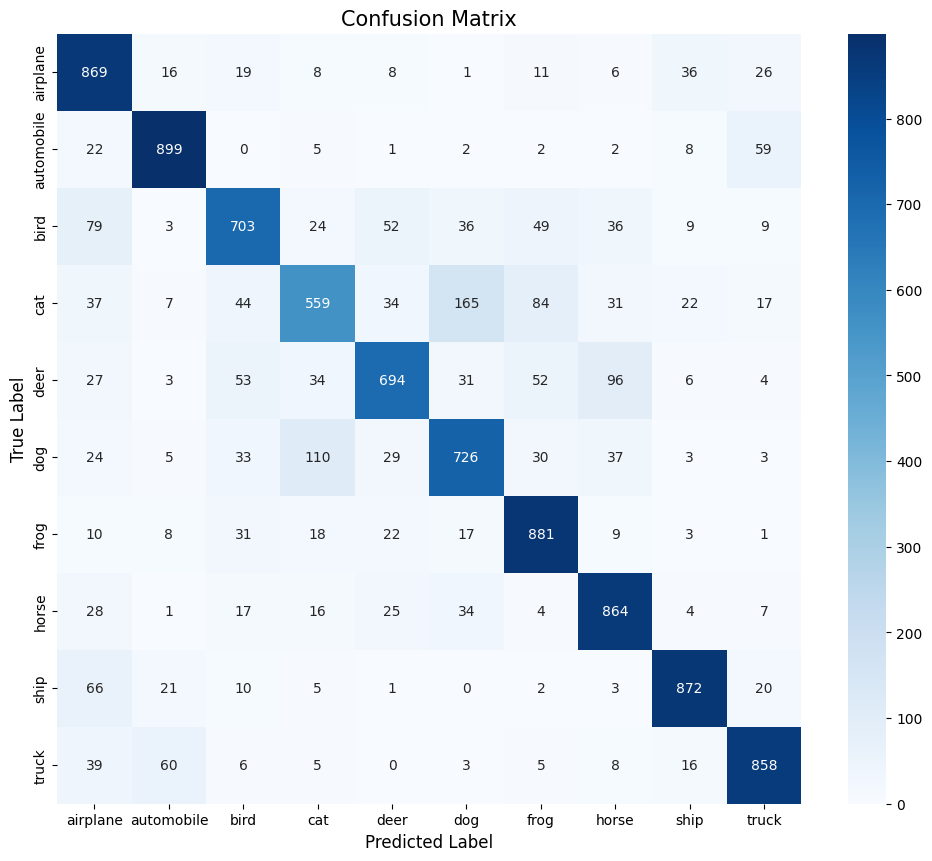

Confusion matrix plot saved to /content/drive/MyDrive/IISc_Submission/base_testing_F0_1/evaluation_results/confusion_matrix.png


In [10]:
# --- base testing ---
main(
    num_runs=1,
    master_seed=100,
    test_name=f'base_testing_F0',
    image_information=ImageParams(width=32, height=32, in_channel=3),
    model_parameters=ModelParameters(patch_size=4, inner_dim=192, transformer_layers=12, num_head=3, embed_dropout=0.1, attn_dropout=0.0, mlp_dropout=0.1),
    hyperparameters=Hyperparameters(batch_size=1024, out_classes=10, epochs=100, learning_rate=5e-4*(1024/512), weight_decay=0.05)
)


--- Starting Run 1/1 (Seed: 200) ---
DataLoaders created successfully.
Training samples: 45000
Validation samples: 5000
Test samples: 10000
Starting Training...
--- Epoch 1/300 ---


Validating: 100%|██████████| 5/5 [00:02<00:00,  1.97it/s]


Epoch 1 Summary:
  Train Loss: 2.2618 | Train Acc: 15.43%
  Val Loss:   2.0639 | Val Acc:   22.18%
  Current Learning Rate: 0.000040
✅ New best model saved with accuracy: 22.18%
--- Epoch 2/300 ---


Validating: 100%|██████████| 5/5 [00:02<00:00,  1.85it/s]


Epoch 2 Summary:
  Train Loss: 2.2046 | Train Acc: 18.23%
  Val Loss:   2.0113 | Val Acc:   25.84%
  Current Learning Rate: 0.000041
✅ New best model saved with accuracy: 25.84%
--- Epoch 3/300 ---


...

Epoch 299 Summary:
  Train Loss: 1.0567 | Train Acc: 79.84%
  Val Loss:   0.3462 | Val Acc:   90.66%
  Current Learning Rate: 0.000000
--- Epoch 300/300 ---


Validating: 100%|██████████| 5/5 [00:02<00:00,  1.84it/s]


Epoch 300 Summary:
  Train Loss: 1.0048 | Train Acc: 82.06%
  Val Loss:   0.3462 | Val Acc:   90.64%
  Current Learning Rate: 0.000000
--- Training Finished ---
Best Validation Accuracy: 90.92%
Training history saved to /content/drive/MyDrive/IISc_Submission/deit_trial_F1_1/training_history.csv

--- Training complete. Starting final evaluation on test set. ---

--- Starting Final Evaluation ---


Testing: 100%|██████████| 10/10 [00:04<00:00,  2.28it/s]



Overall Test Accuracy: 90.66%

Classification Report:
                  precision  recall  f1-score     support  accuracy
airplane           0.901047  0.9470  0.923452   1000.0000    0.9470
automobile         0.945044  0.9630  0.953938   1000.0000    0.9630
bird               0.873281  0.8890  0.881070   1000.0000    0.8890
cat                0.839191  0.7880  0.812790   1000.0000    0.7880
deer               0.906054  0.8680  0.886619   1000.0000    0.8680
dog                0.848089  0.8430  0.845537   1000.0000    0.8430
frog               0.906310  0.9480  0.926686   1000.0000    0.9480
horse              0.940464  0.9320  0.936213   1000.0000    0.9320
ship               0.960646  0.9520  0.956303   1000.0000    0.9520
truck              0.942598  0.9360  0.939288   1000.0000    0.9360
accuracy           0.906600  0.9066  0.906600      0.9066    0.9066
macro avg          0.906272  0.9066  0.906190  10000.0000       NaN
weighted avg       0.906272  0.9066  0.906190  10000.0000    

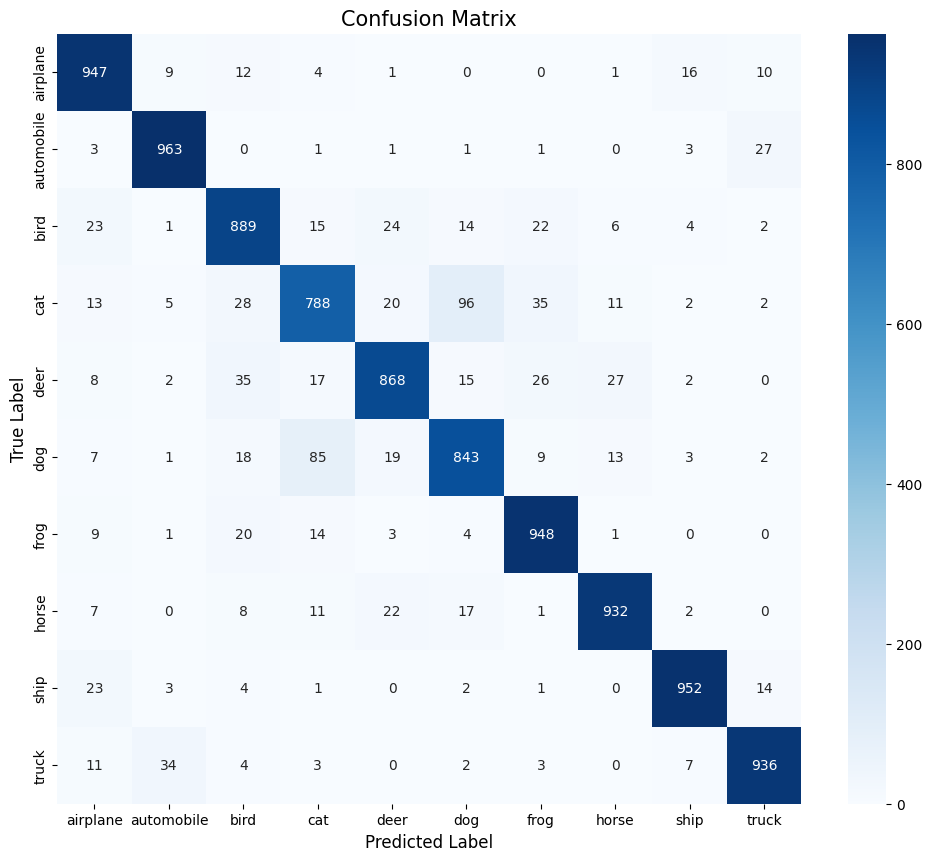

Confusion matrix plot saved to /content/drive/MyDrive/IISc_Submission/deit_trial_F1_1/evaluation_results/confusion_matrix.png


In [11]:
# --- trying to run for 300 epochs like DeiT paper
main(
    num_runs=1,
    master_seed=200,
    test_name=f'deit_trial_F1',
    image_information=ImageParams(width=32, height=32, in_channel=3),
    model_parameters=ModelParameters(patch_size=4, inner_dim=192, transformer_layers=12, num_head=3, embed_dropout=0.1, attn_dropout=0.0, mlp_dropout=0.1),
    hyperparameters=Hyperparameters(batch_size=1024, out_classes=10, epochs=300, learning_rate=5e-4*(1024/512), weight_decay=0.05)
)



--- Training complete. Starting final evaluation on test set. ---
DataLoaders created successfully.
Training samples: 45000
Validation samples: 5000
Test samples: 10000

--- Starting Final Evaluation ---


Testing: 100%|██████████| 10/10 [03:16<00:00, 19.66s/it]



Overall Test Accuracy: 90.66%

Classification Report:
                  precision  recall  f1-score     support  accuracy
airplane           0.901047  0.9470  0.923452   1000.0000    0.9470
automobile         0.945044  0.9630  0.953938   1000.0000    0.9630
bird               0.873281  0.8890  0.881070   1000.0000    0.8890
cat                0.839191  0.7880  0.812790   1000.0000    0.7880
deer               0.906054  0.8680  0.886619   1000.0000    0.8680
dog                0.848089  0.8430  0.845537   1000.0000    0.8430
frog               0.906310  0.9480  0.926686   1000.0000    0.9480
horse              0.940464  0.9320  0.936213   1000.0000    0.9320
ship               0.960646  0.9520  0.956303   1000.0000    0.9520
truck              0.942598  0.9360  0.939288   1000.0000    0.9360
accuracy           0.906600  0.9066  0.906600      0.9066    0.9066
macro avg          0.906272  0.9066  0.906190  10000.0000       NaN
weighted avg       0.906272  0.9066  0.906190  10000.0000    

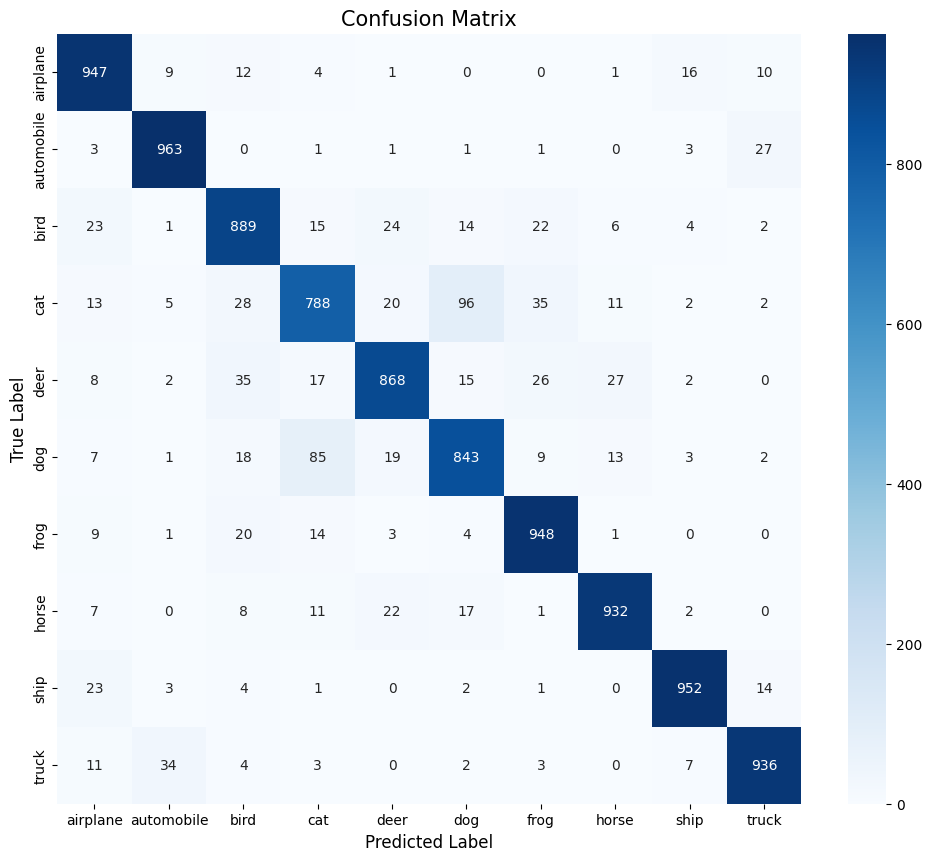

Confusion matrix plot saved to /content/drive/MyDrive/IISc_Submission/deit_trial_F1_1/evaluation_results/confusion_matrix.png


In [12]:
# -- trying to test on 257/300 epoch model
print("\n--- Training complete. Starting final evaluation on test set. ---")
img_info = ImageParams(width=32, height=32, in_channel=3)
mparams =ModelParameters(patch_size=4, inner_dim=192, transformer_layers=12, num_head=3, embed_dropout=0.1, attn_dropout=0.0, mlp_dropout=0.1)
hparams = Hyperparameters(batch_size=1024, out_classes=10, epochs=300, learning_rate=5e-4*(1024/512), weight_decay=0.05)
data_handler = DataHandler(image_information=img_info, batch_size=hparams.batch_size)
train_loader, val_loader, test_loader = data_handler.get_dataloaders()
run_name = f'deit_trial_F1_1'
run_output_dir = f"/content/drive/MyDrive/IISc_Submission/{run_name}" # SAVING TO DRIVE
local_model_path = os.path.join(run_output_dir, "best_model.pth")
eval_results_dir = os.path.join(run_output_dir, "evaluation_results")
evaluator = Evaluator(
model=ViT(mparams=mparams, hparams=hparams, img_info=img_info),
test_loader=test_loader,
device='cpu',
output_dir=eval_results_dir)
final_metrics = evaluator.evaluate(model_path=local_model_path)

# Abalation Study: Effect of MixUp and CutMix
1. disabled `cutmix` and `mixup` and run the model for 30 epochs
1. did not disable `cutmix` and `mixup` and run the model for 30 epochs


--- Starting Run 1/1 (Seed: 300) ---
DataLoaders created successfully.
Training samples: 45000
Validation samples: 5000
Test samples: 10000
Starting Training...
--- Epoch 1/30 ---


Validating: 100%|██████████| 5/5 [00:02<00:00,  1.87it/s]


Epoch 1 Summary:
  Train Loss: 2.2490 | Train Acc: 15.89%
  Val Loss:   2.0537 | Val Acc:   22.42%
  Current Learning Rate: 0.000069
✅ New best model saved with accuracy: 22.42%
--- Epoch 2/30 ---


Validating: 100%|██████████| 5/5 [00:02<00:00,  2.11it/s]


Epoch 2 Summary:
  Train Loss: 2.1962 | Train Acc: 18.90%
  Val Loss:   2.0050 | Val Acc:   26.70%
  Current Learning Rate: 0.000153
✅ New best model saved with accuracy: 26.70%
--- Epoch 3/30 ---


...

Epoch 29 Summary:
  Train Loss: 1.7767 | Train Acc: 43.58%
  Val Loss:   1.0728 | Val Acc:   63.62%
  Current Learning Rate: 0.000005
--- Epoch 30/30 ---


Validating: 100%|██████████| 5/5 [00:02<00:00,  1.87it/s]


Epoch 30 Summary:
  Train Loss: 1.7190 | Train Acc: 47.61%
  Val Loss:   1.0702 | Val Acc:   63.76%
  Current Learning Rate: 0.000000
--- Training Finished ---
Best Validation Accuracy: 64.42%
Training history saved to /content/drive/MyDrive/IISc_Submission/baseline_vit_abalation_F0_1/training_history.csv

--- Training complete. Starting final evaluation on test set. ---

--- Starting Final Evaluation ---


Testing: 100%|██████████| 10/10 [00:04<00:00,  2.16it/s]



Overall Test Accuracy: 64.39%

Classification Report:
                  precision  recall  f1-score     support  accuracy
airplane           0.601958  0.7380  0.663073   1000.0000    0.7380
automobile         0.690395  0.8050  0.743306   1000.0000    0.8050
bird               0.519871  0.4840  0.501295   1000.0000    0.4840
cat                0.574713  0.3500  0.435053   1000.0000    0.3500
deer               0.658667  0.4940  0.564571   1000.0000    0.4940
dog                0.568226  0.5830  0.575518   1000.0000    0.5830
frog               0.648298  0.8000  0.716204   1000.0000    0.8000
horse              0.666667  0.7340  0.698715   1000.0000    0.7340
ship               0.755278  0.7870  0.770813   1000.0000    0.7870
truck              0.725683  0.6640  0.693473   1000.0000    0.6640
accuracy           0.643900  0.6439  0.643900      0.6439    0.6439
macro avg          0.640975  0.6439  0.636202  10000.0000       NaN
weighted avg       0.640975  0.6439  0.636202  10000.0000    

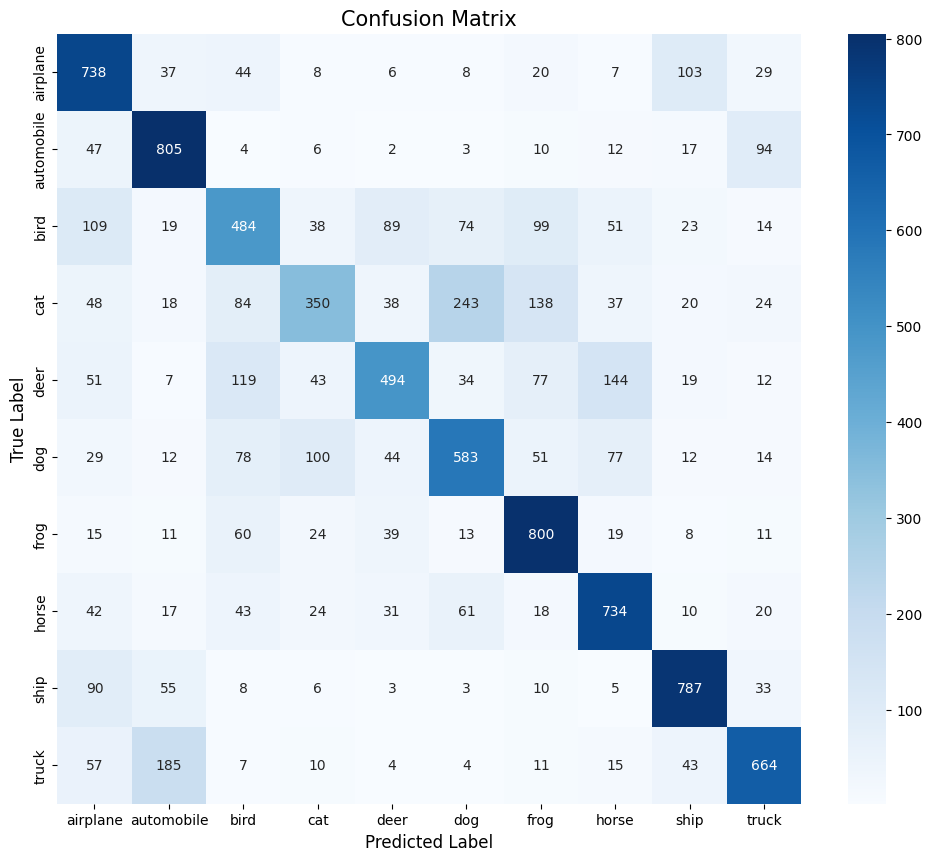

Confusion matrix plot saved to /content/drive/MyDrive/IISc_Submission/baseline_vit_abalation_F0_1/evaluation_results/confusion_matrix.png


In [13]:
# --- baseline_vit_abalation ---
main(
    num_runs=1,
    master_seed=300,
    test_name=f'baseline_vit_abalation_F0',
    image_information=ImageParams(width=32, height=32, in_channel=3),
    model_parameters=ModelParameters(patch_size=4, inner_dim=192, transformer_layers=12, num_head=3, embed_dropout=0.1, attn_dropout=0.0, mlp_dropout=0.1),
    hyperparameters=Hyperparameters(batch_size=1024, out_classes=10, epochs=30, learning_rate=5e-4*(1024/512), weight_decay=0.05)
)


--- Starting Run 1/1 (Seed: 350) ---
DataLoaders created successfully.
Training samples: 45000
Validation samples: 5000
Test samples: 10000
Starting Training...
--- Epoch 1/30 ---


Validating: 100%|██████████| 5/5 [00:02<00:00,  2.08it/s]


Epoch 1 Summary:
  Train Loss: 2.2680 | Train Acc: 15.41%
  Val Loss:   2.0686 | Val Acc:   20.28%
  Current Learning Rate: 0.000069
✅ New best model saved with accuracy: 20.28%
--- Epoch 2/30 ---


Validating: 100%|██████████| 5/5 [00:02<00:00,  2.03it/s]


Epoch 2 Summary:
  Train Loss: 2.2023 | Train Acc: 18.57%
  Val Loss:   1.9774 | Val Acc:   27.00%
  Current Learning Rate: 0.000153
✅ New best model saved with accuracy: 27.00%
--- Epoch 3/30 ---


...

Epoch 29 Summary:
  Train Loss: 1.7727 | Train Acc: 43.68%
  Val Loss:   1.0752 | Val Acc:   63.74%
  Current Learning Rate: 0.000005
✅ New best model saved with accuracy: 63.74%
--- Epoch 30/30 ---


Validating: 100%|██████████| 5/5 [00:02<00:00,  1.89it/s]


Epoch 30 Summary:
  Train Loss: 1.7393 | Train Acc: 45.69%
  Val Loss:   1.0764 | Val Acc:   63.52%
  Current Learning Rate: 0.000000
--- Training Finished ---
Best Validation Accuracy: 63.74%
Training history saved to /content/drive/MyDrive/IISc_Submission/mixupcutmix_testing_F0_1/training_history.csv

--- Training complete. Starting final evaluation on test set. ---

--- Starting Final Evaluation ---


Testing: 100%|██████████| 10/10 [00:04<00:00,  2.31it/s]



Overall Test Accuracy: 63.61%

Classification Report:
                  precision  recall  f1-score     support  accuracy
airplane           0.576426  0.7580  0.654860   1000.0000    0.7580
automobile         0.696157  0.7790  0.735252   1000.0000    0.7790
bird               0.540598  0.5060  0.522727   1000.0000    0.5060
cat                0.573770  0.3150  0.406714   1000.0000    0.3150
deer               0.647541  0.4740  0.547344   1000.0000    0.4740
dog                0.558994  0.5780  0.568338   1000.0000    0.5780
frog               0.620690  0.8100  0.702820   1000.0000    0.8100
horse              0.650264  0.7400  0.692236   1000.0000    0.7400
ship               0.747115  0.7770  0.761765   1000.0000    0.7770
truck              0.750000  0.6240  0.681223   1000.0000    0.6240
accuracy           0.636100  0.6361  0.636100      0.6361    0.6361
macro avg          0.636156  0.6361  0.627328  10000.0000       NaN
weighted avg       0.636156  0.6361  0.627328  10000.0000    

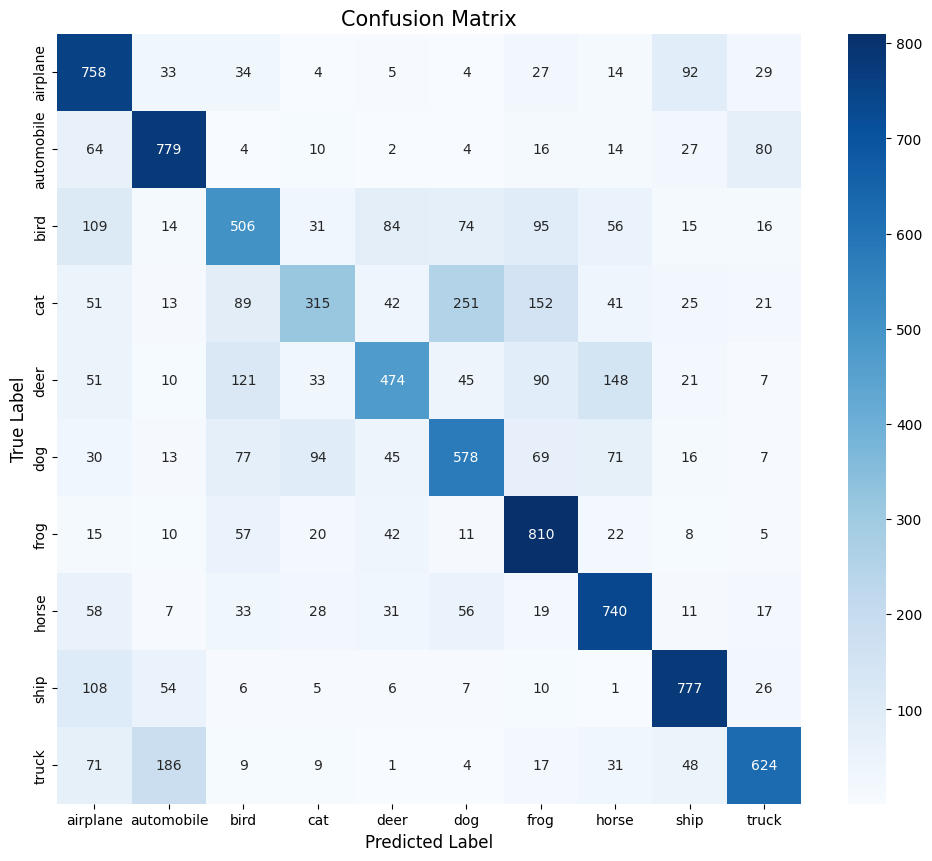

Confusion matrix plot saved to /content/drive/MyDrive/IISc_Submission/mixupcutmix_testing_F0_1/evaluation_results/confusion_matrix.png


In [14]:
# --- mixupcutmix_vit_abalation  ---
main(
    num_runs=1,
    master_seed=350,
    test_name=f'mixupcutmix_testing_F0',
    image_information=ImageParams(width=32, height=32, in_channel=3),
    model_parameters=ModelParameters(patch_size=4, inner_dim=192, transformer_layers=12, num_head=3, embed_dropout=0.1, attn_dropout=0.0, mlp_dropout=0.1),
    hyperparameters=Hyperparameters(batch_size=1024, out_classes=10, epochs=30, learning_rate=5e-4*(1024/512), weight_decay=0.05)
)

# Evaluate Best Trained ViT Model

This cell runs the **final evaluation** on the CIFAR-10 test set using the best pre-trained model.

> **Note:** Make sure you have:  
> 1. Uploaded the pretrained model folder from [GitHub/Drive](https://github.com/Aleptonic/IISC-VIT/edit/main/README.md)  
> 2. Mounted your Google Drive in Colab (`from google.colab import drive; drive.mount('/content/drive')`)  




--- Starting final evaluation on the test set ---
DataLoaders created successfully.
Training samples: 45000
Validation samples: 5000
Test samples: 10000

--- Starting Final Evaluation ---


Testing: 100%|██████████| 10/10 [03:16<00:00, 19.65s/it]



Overall Test Accuracy: 90.66%

Classification Report:
                  precision  recall  f1-score     support  accuracy
airplane           0.901047  0.9470  0.923452   1000.0000    0.9470
automobile         0.945044  0.9630  0.953938   1000.0000    0.9630
bird               0.873281  0.8890  0.881070   1000.0000    0.8890
cat                0.839191  0.7880  0.812790   1000.0000    0.7880
deer               0.906054  0.8680  0.886619   1000.0000    0.8680
dog                0.848089  0.8430  0.845537   1000.0000    0.8430
frog               0.906310  0.9480  0.926686   1000.0000    0.9480
horse              0.940464  0.9320  0.936213   1000.0000    0.9320
ship               0.960646  0.9520  0.956303   1000.0000    0.9520
truck              0.942598  0.9360  0.939288   1000.0000    0.9360
accuracy           0.906600  0.9066  0.906600      0.9066    0.9066
macro avg          0.906272  0.9066  0.906190  10000.0000       NaN
weighted avg       0.906272  0.9066  0.906190  10000.0000    

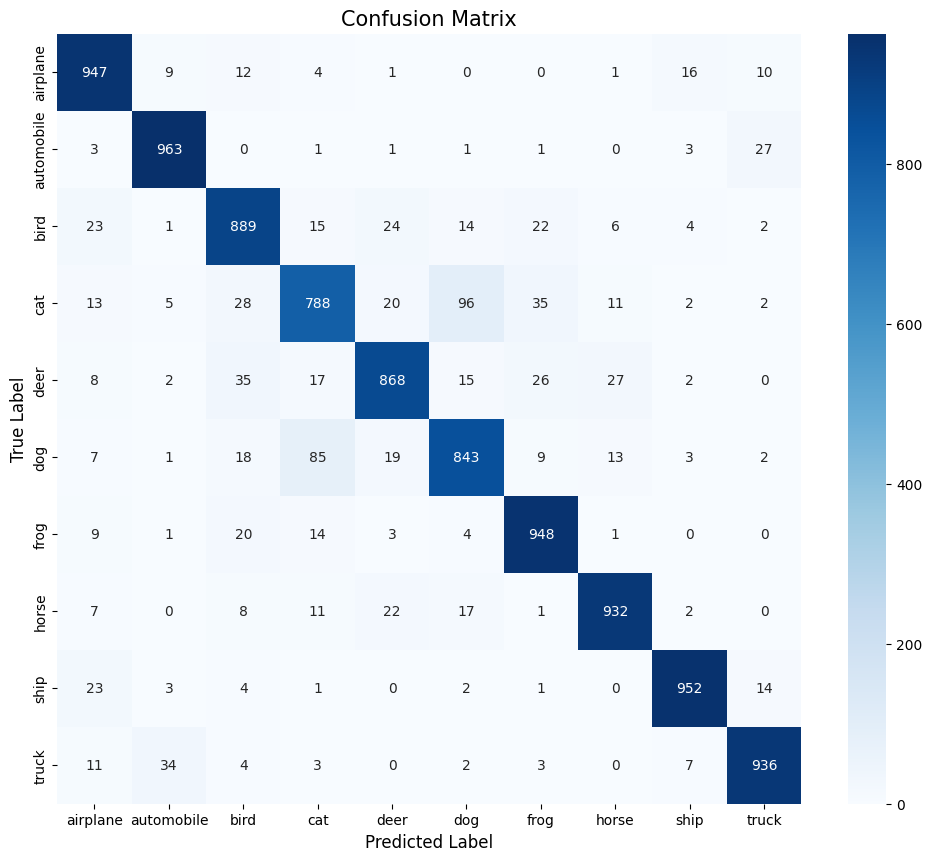

Confusion matrix plot saved to /content/drive/MyDrive/IISc_Submission/deit_trial_F1_1/evaluation_results/confusion_matrix.png


In [15]:
# --- Imports ---
import os
import pandas as pd

# --- Setup ---
print("\n--- Starting final evaluation on the test set ---")

# Image and model parameters
img_info = ImageParams(width=32, height=32, in_channel=3)
mparams = ModelParameters(
    patch_size=4,
    inner_dim=192,
    transformer_layers=12,
    num_head=3,
    embed_dropout=0.1,
    attn_dropout=0.0,
    mlp_dropout=0.1
)
hparams = Hyperparameters(
    batch_size=1024,
    out_classes=10,
    epochs=300,
    learning_rate=5e-4 * (1024/512),
    weight_decay=0.05
)

# --- Data Loading ---
data_handler = DataHandler(image_information=img_info, batch_size=hparams.batch_size)
train_loader, val_loader, test_loader = data_handler.get_dataloaders()

# --- Paths ---
run_name = 'deit_trial_F1_1'
run_output_dir = f"/content/drive/MyDrive/IISc_Submission/{run_name}"  # Folder in mounted Drive
local_model_path = os.path.join(run_output_dir, "best_model.pth")
eval_results_dir = os.path.join(run_output_dir, "evaluation_results")

# --- Evaluation ---
evaluator = Evaluator(
    model=ViT(mparams=mparams, hparams=hparams, img_info=img_info),
    test_loader=test_loader,
    device='cpu',  # Switch to 'cuda' if GPU available and limits allow
    output_dir=eval_results_dir
)

# Run evaluation
final_metrics = evaluator.evaluate(model_path=local_model_path)
